In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/agneaybnair/hr-new/Practice_HR-Employee-Attrition-All.xlsx


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_excel("/kaggle/input/datasets/agneaybnair/hr-new/Practice_HR-Employee-Attrition-All.xlsx")

In [4]:
df.shape
df.info()
df.describe().T
df.describe(include='object').T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

,count,unique,top,freq
Attrition,1470,2,No,1233
BusinessTravel,1470,3,Travel_Rarely,1043
Department,1470,3,Research & Development,961
EducationField,1470,6,Life Sciences,606
Gender,1470,2,Male,882
JobRole,1470,9,Sales Executive,326
MaritalStatus,1470,3,Married,673
Over18,1470,1,Y,1470
OverTime,1470,2,No,1054


In [5]:
df.isnull().sum().sort_values(ascending=False)

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

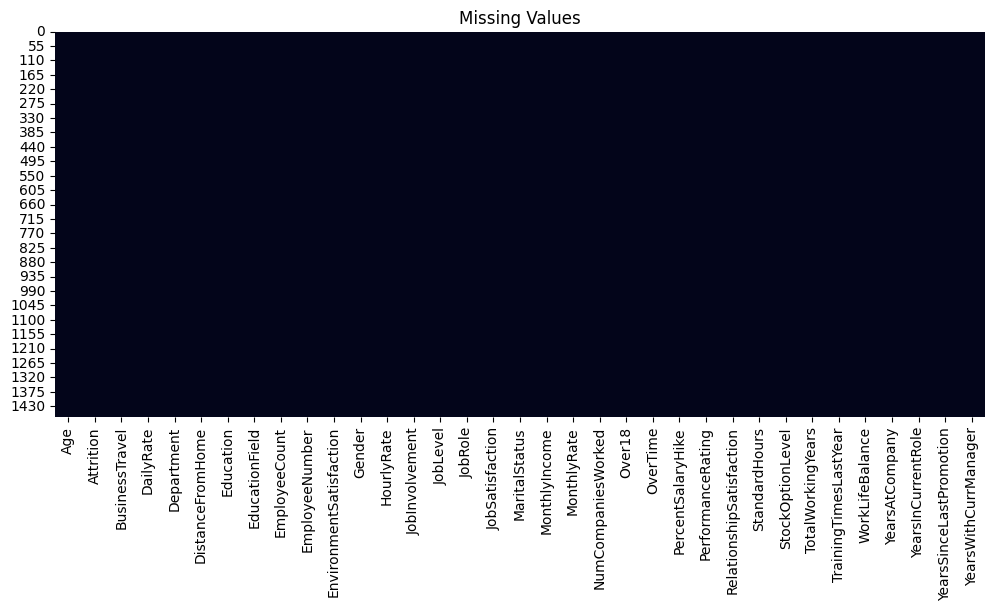

In [6]:
plt.figure(figsize=(12,5))
sns.heatmap(df.isnull(),cbar=False)
plt.title("Missing Values")
plt.show()

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
for col in df.columns:
    if df[col].nunique()==1:
        print(col)

EmployeeCount
Over18
StandardHours


In [9]:
df=df.drop(columns=['EmployeeCount','Over18','StandardHours'])

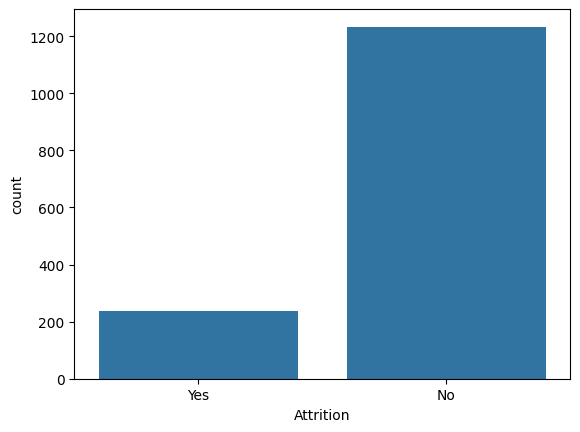

Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64

In [10]:
sns.countplot(x='Attrition',data=df)
plt.show()

df['Attrition'].value_counts(normalize=True)*100

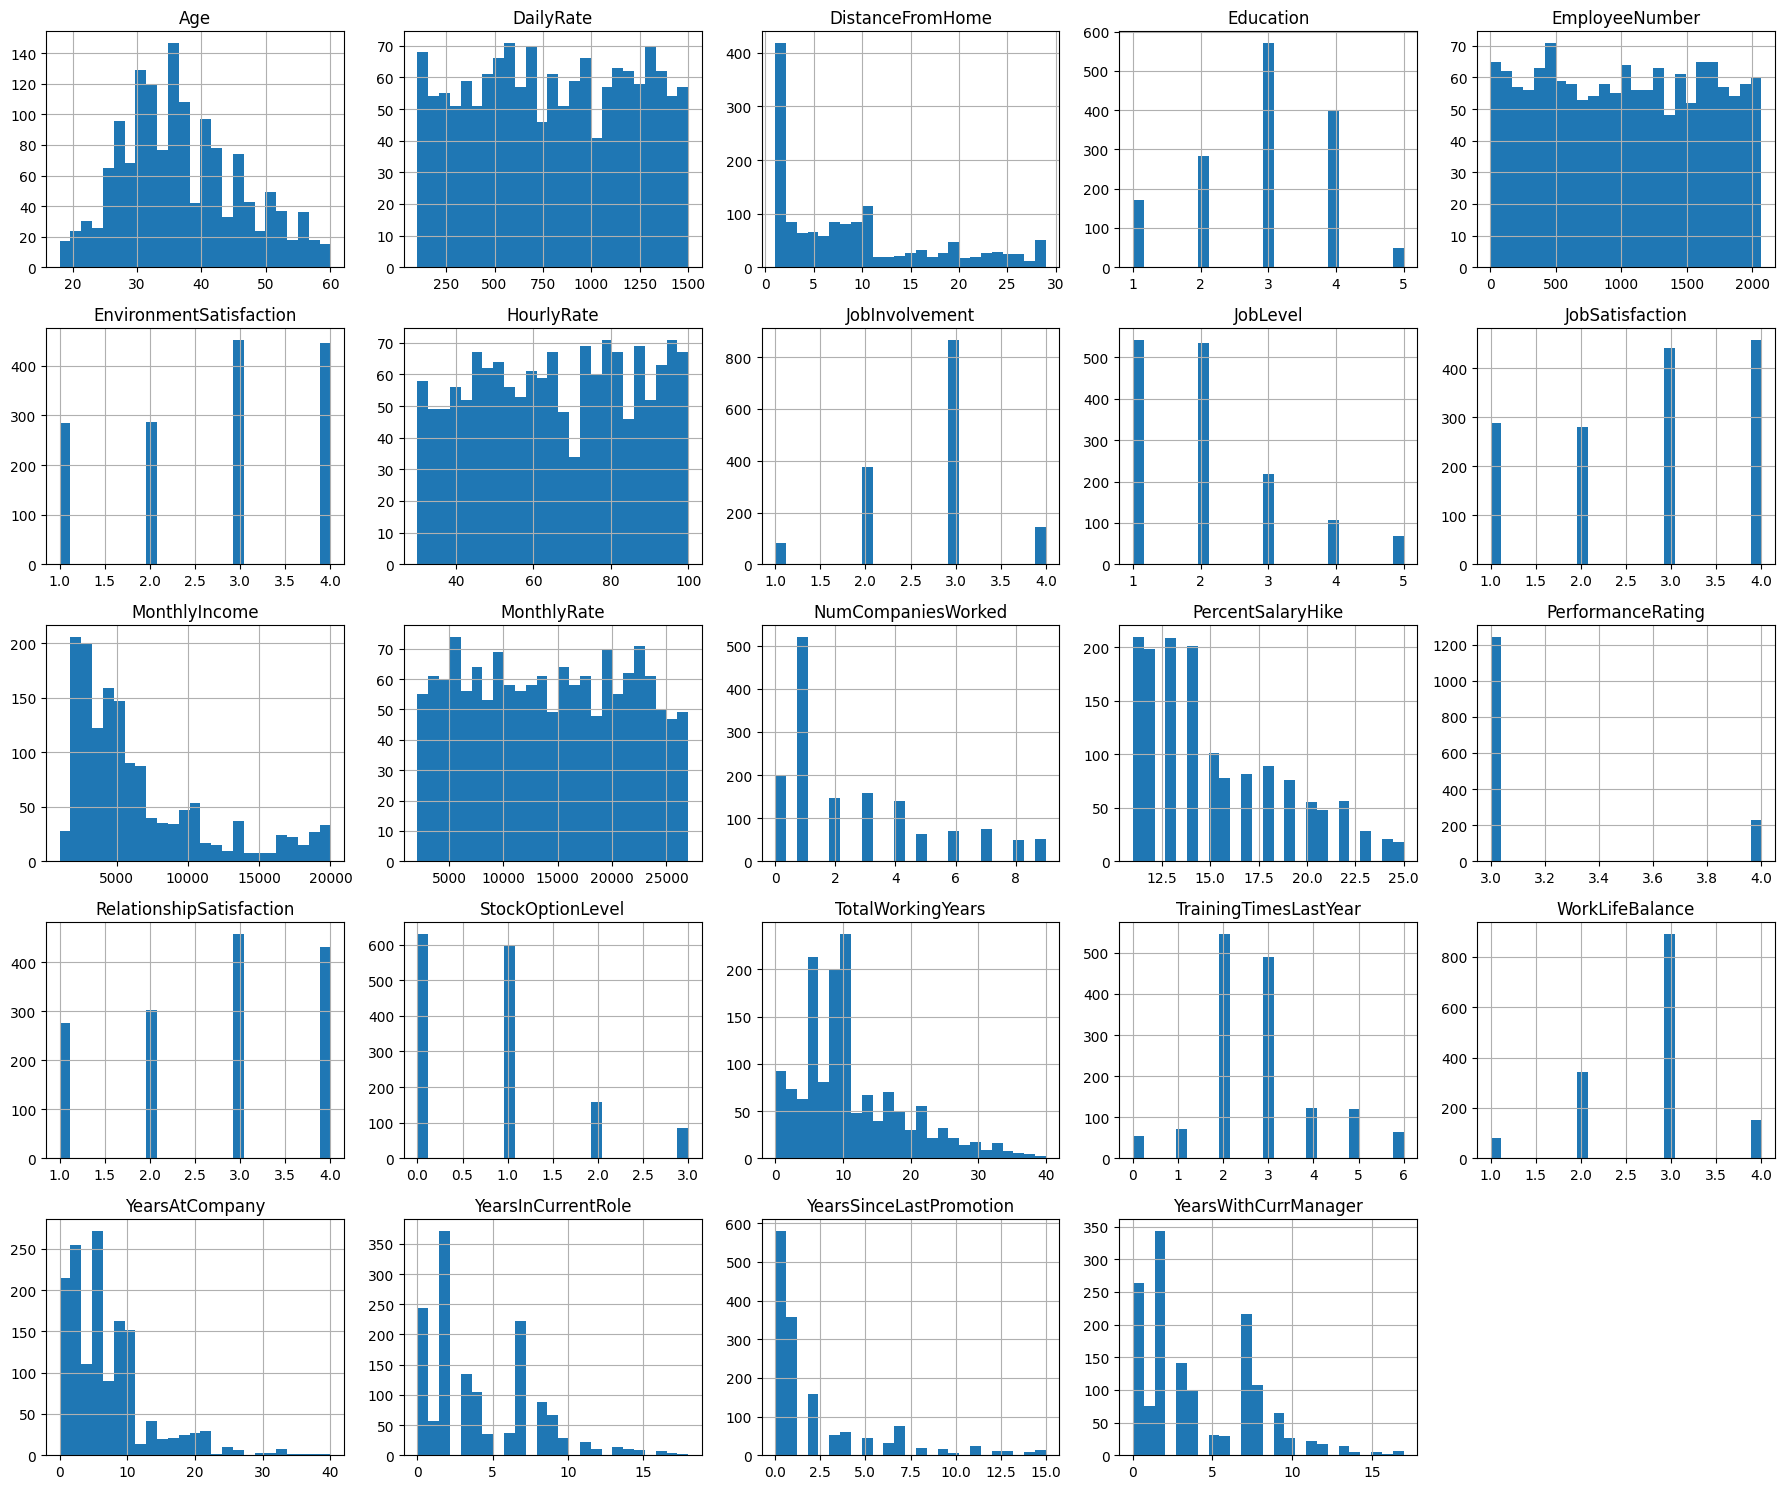

In [11]:
df.hist(figsize=(18,15),bins=25)
plt.tight_layout()

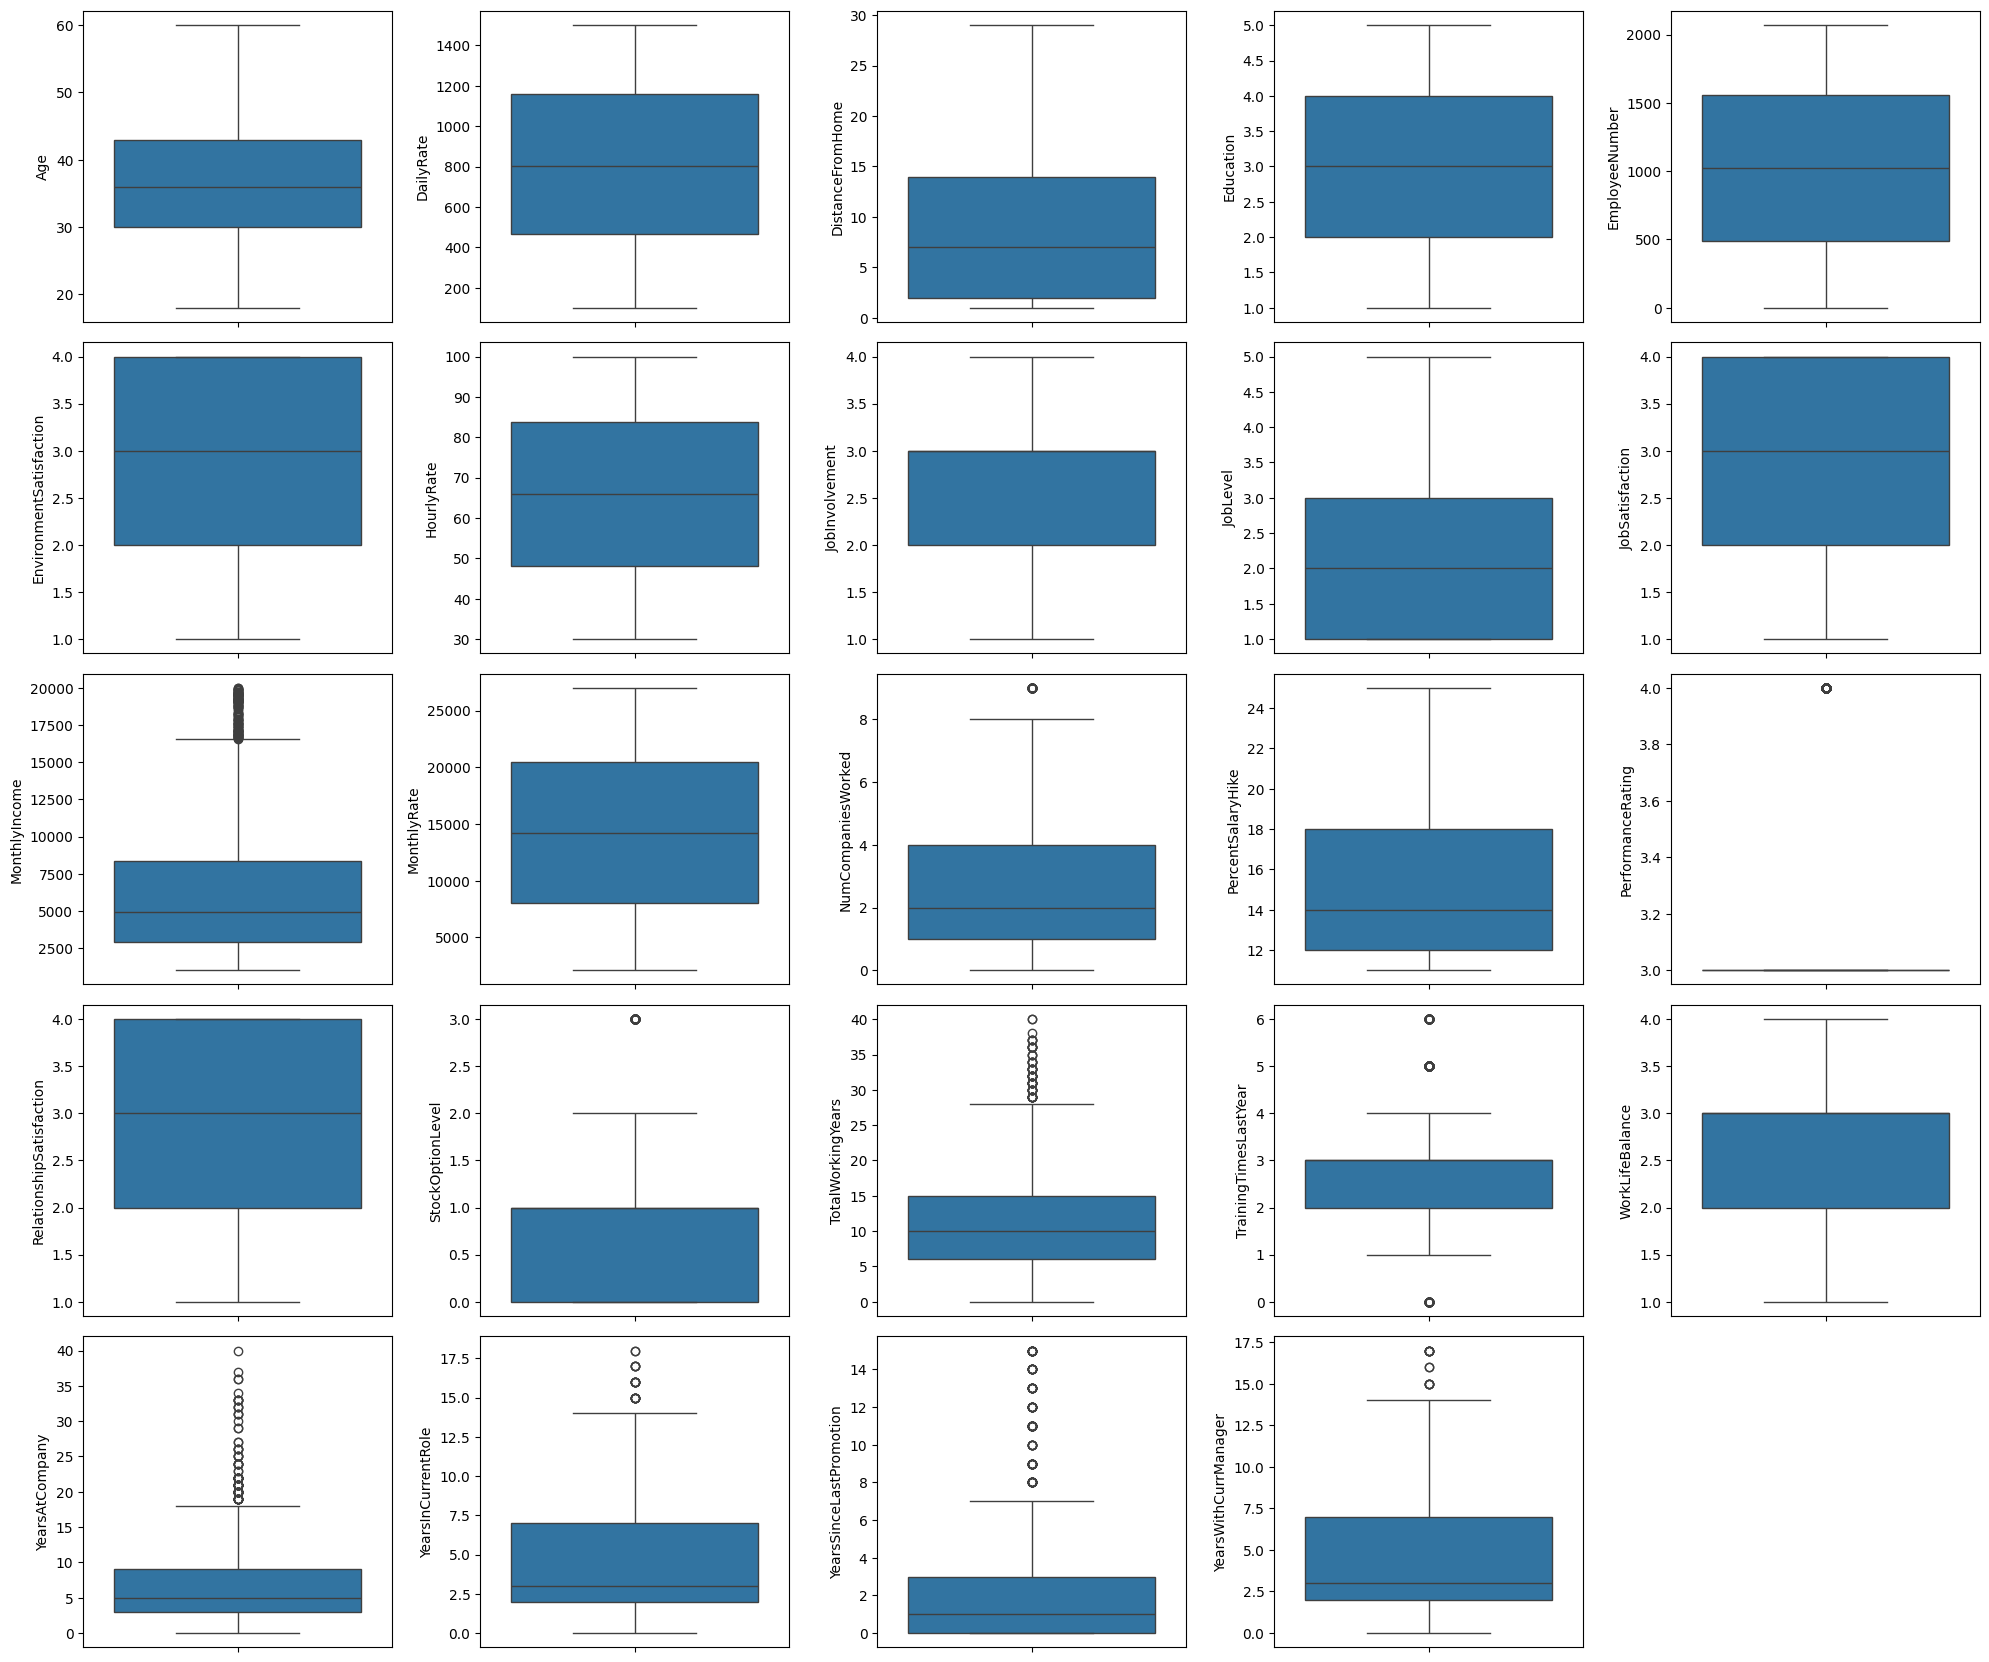

In [12]:
num_cols=df.select_dtypes(include='number').columns

plt.figure(figsize=(20,20))

for i,col in enumerate(num_cols):
    plt.subplot(6,5,i+1)
    sns.boxplot(y=df[col])

plt.tight_layout()

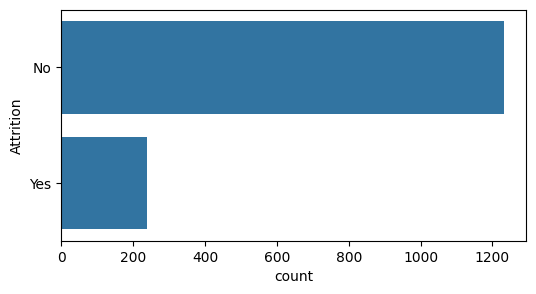

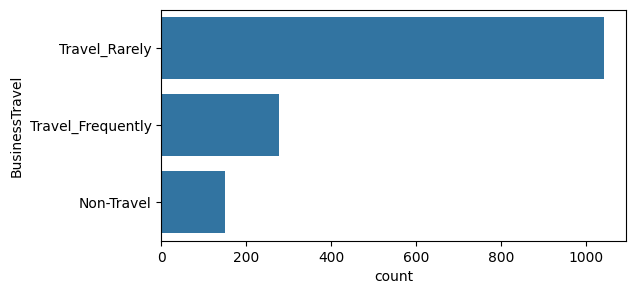

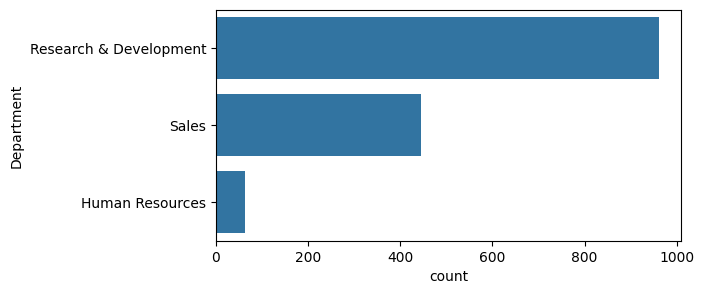

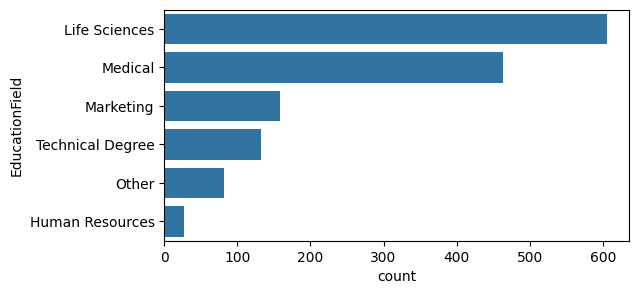

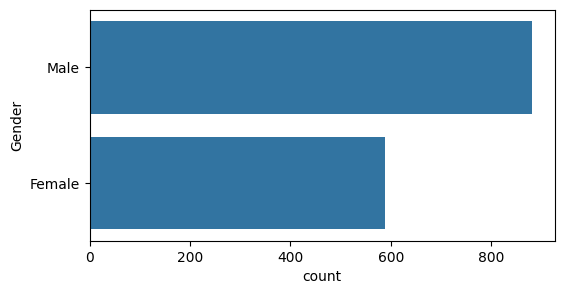

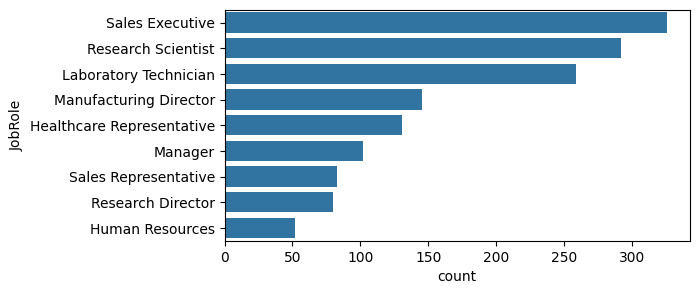

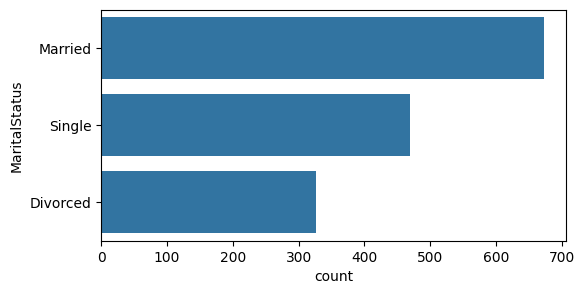

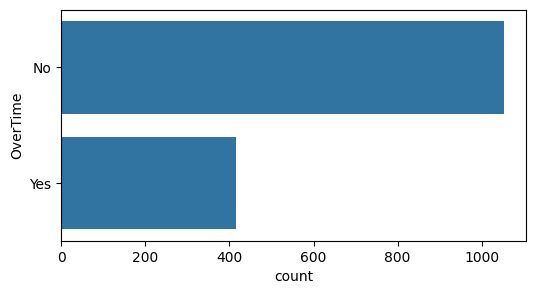

In [13]:
cat_cols=df.select_dtypes(include='object').columns

for col in cat_cols:
    plt.figure(figsize=(6,3))
    sns.countplot(y=col,data=df,order=df[col].value_counts().index)
    plt.show()

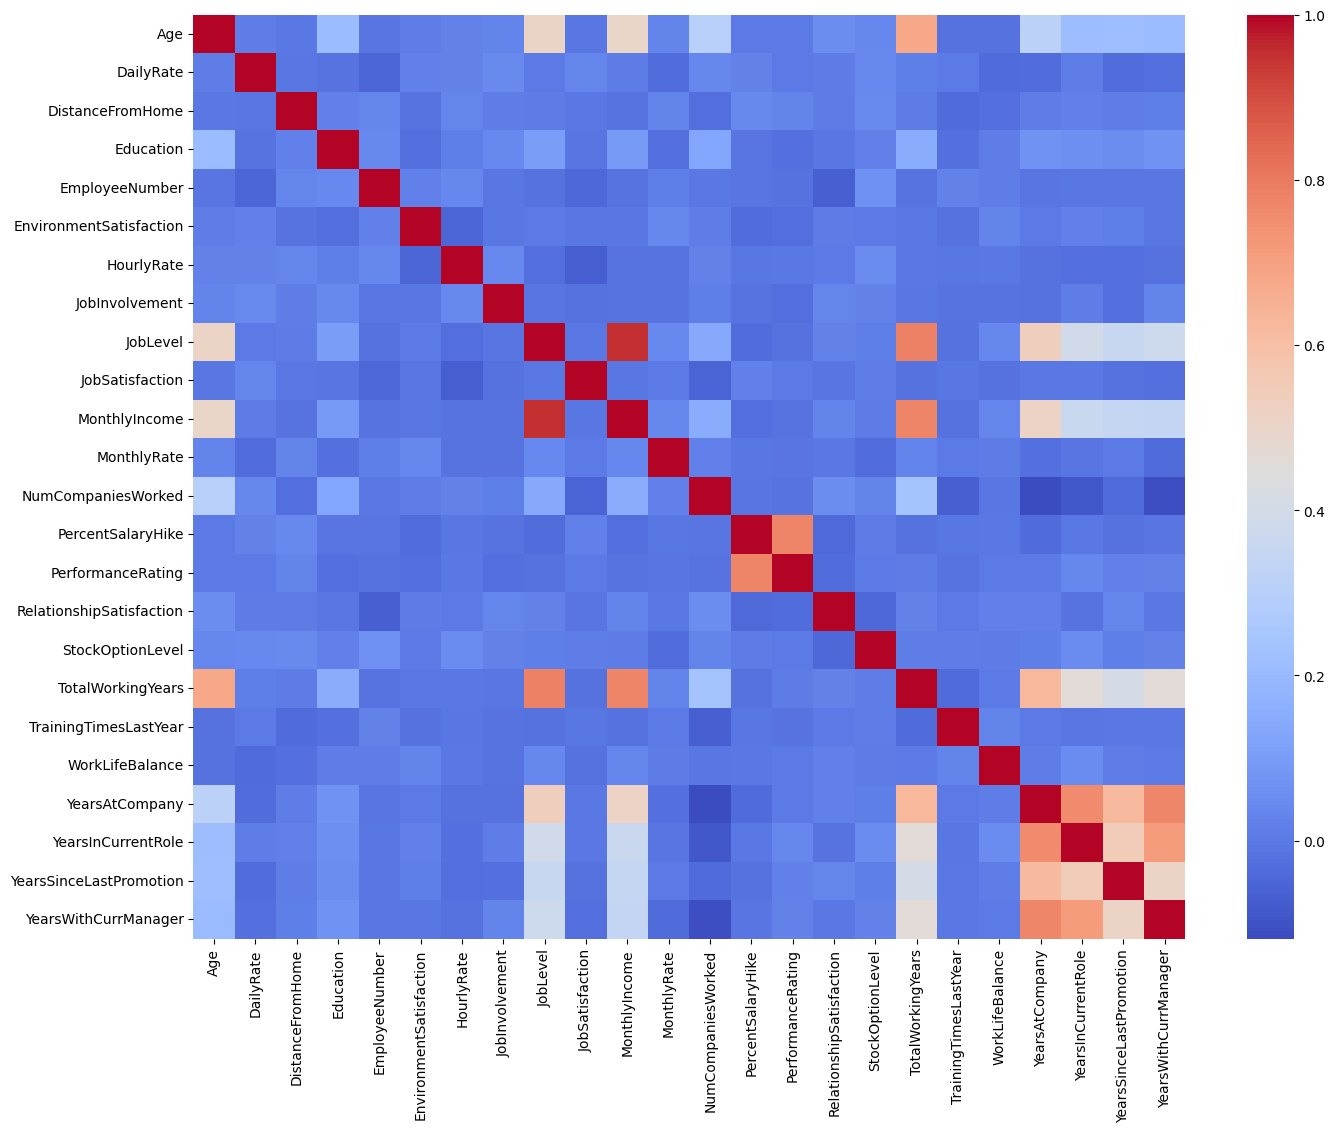

In [16]:
plt.figure(figsize=(16,12))

sns.heatmap(df.corr(numeric_only=True),
            cmap='coolwarm',
            annot=False)

plt.show()

In [17]:
df['AttritionBinary']=df['Attrition'].map({'Yes':1,'No':0})

corr=df.corr(numeric_only=True)['AttritionBinary'].sort_values()

corr

TotalWorkingYears          -0.171063
JobLevel                   -0.169105
YearsInCurrentRole         -0.160545
MonthlyIncome              -0.159840
Age                        -0.159205
YearsWithCurrManager       -0.156199
StockOptionLevel           -0.137145
YearsAtCompany             -0.134392
JobInvolvement             -0.130016
JobSatisfaction            -0.103481
EnvironmentSatisfaction    -0.103369
WorkLifeBalance            -0.063939
TrainingTimesLastYear      -0.059478
DailyRate                  -0.056652
RelationshipSatisfaction   -0.045872
YearsSinceLastPromotion    -0.033019
Education                  -0.031373
PercentSalaryHike          -0.013478
EmployeeNumber             -0.010577
HourlyRate                 -0.006846
PerformanceRating           0.002889
MonthlyRate                 0.015170
NumCompaniesWorked          0.043494
DistanceFromHome            0.077924
AttritionBinary             1.000000
Name: AttritionBinary, dtype: float64

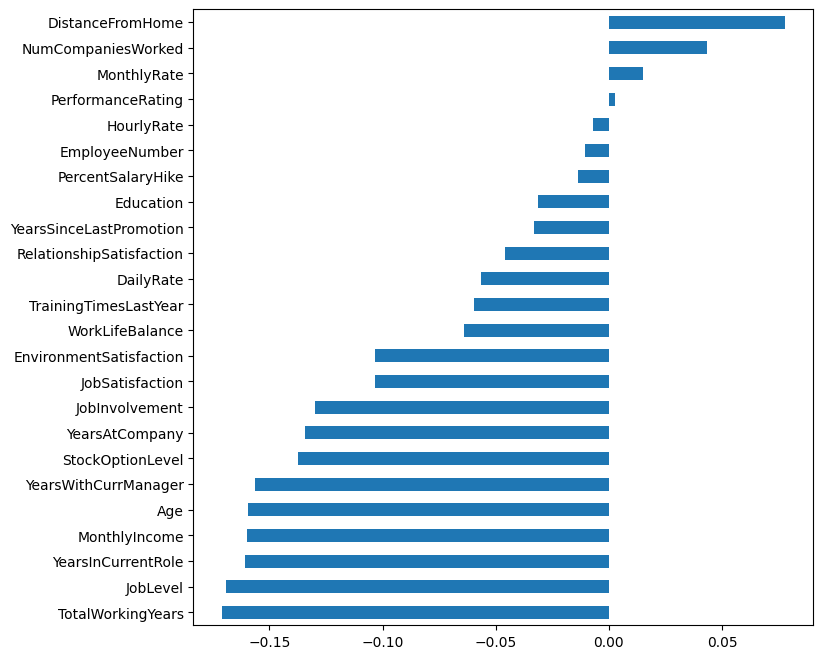

In [18]:
corr.drop('AttritionBinary').plot.barh(figsize=(8,8))
plt.show()

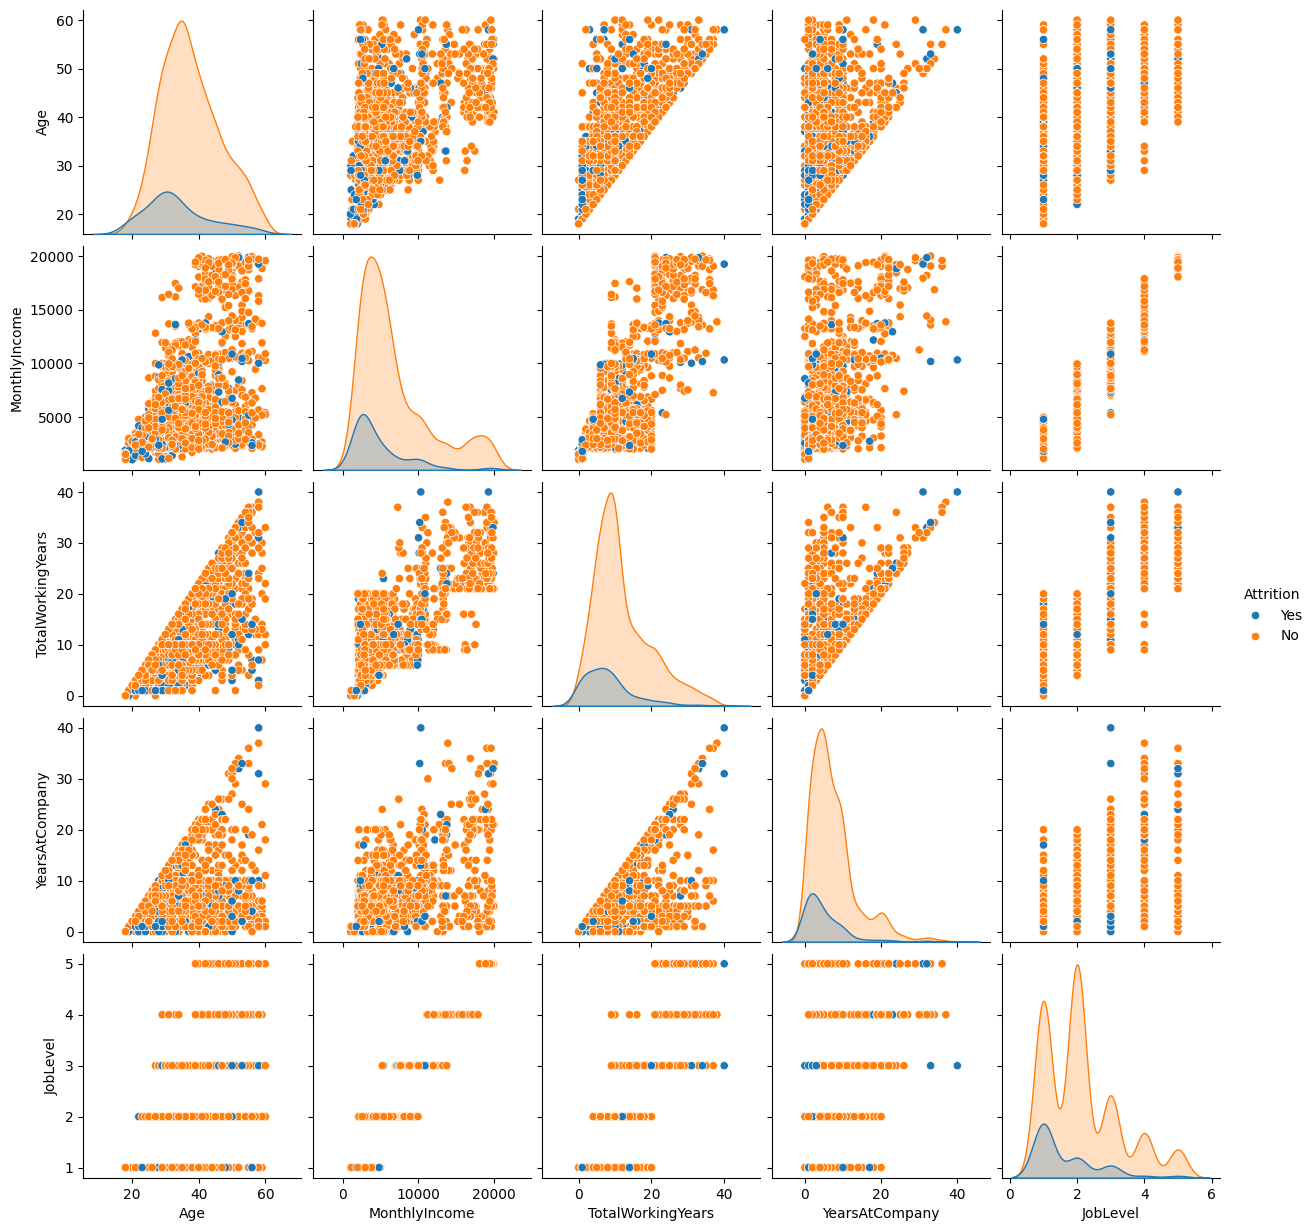

In [19]:
cols=[
'Age',
'MonthlyIncome',
'TotalWorkingYears',
'YearsAtCompany',
'JobLevel',
'Attrition'
]

sns.pairplot(df[cols],hue='Attrition')

<Axes: xlabel='Department', ylabel='count'>

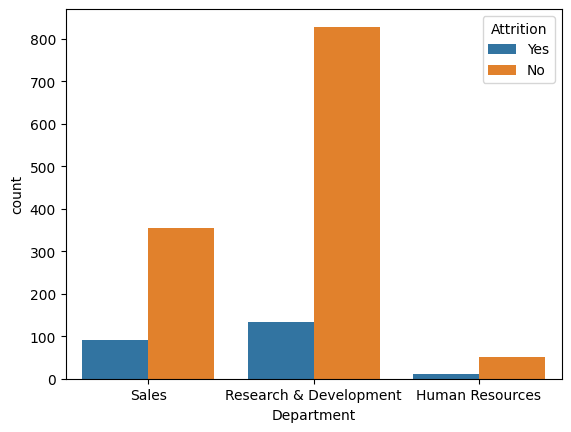

In [20]:
sns.countplot(
x='Department',
hue='Attrition',
data=df
)

<Axes: xlabel='count', ylabel='JobRole'>

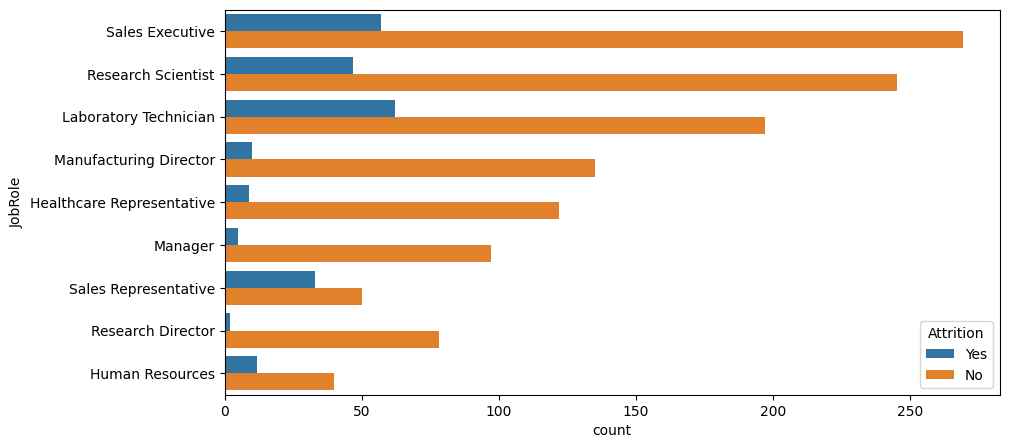

In [21]:
plt.figure(figsize=(10,5))

sns.countplot(
y='JobRole',
hue='Attrition',
data=df
)

<Axes: xlabel='Gender', ylabel='count'>

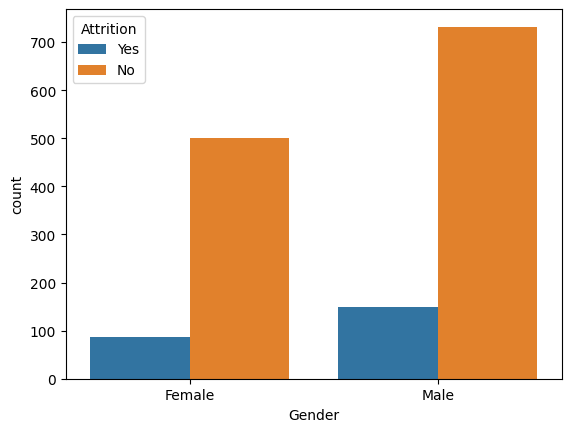

In [22]:
sns.countplot(
x='Gender',
hue='Attrition',
data=df
)

<Axes: xlabel='OverTime', ylabel='count'>

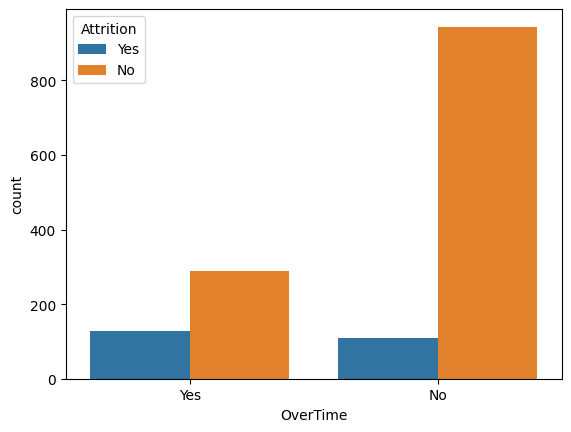

In [23]:
sns.countplot(
x='OverTime',
hue='Attrition',
data=df
)

<Axes: xlabel='Attrition', ylabel='MonthlyIncome'>

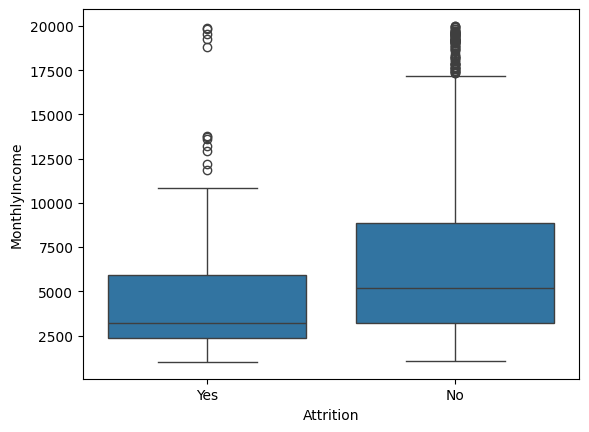

In [24]:
sns.boxplot(
x='Attrition',
y='MonthlyIncome',
data=df
)

<Axes: xlabel='Age', ylabel='Count'>

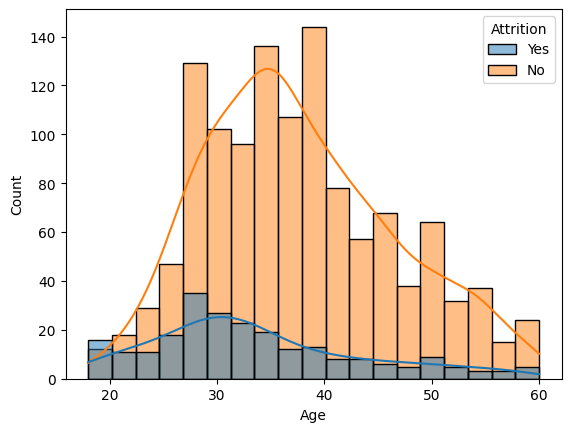

In [25]:
sns.histplot(
data=df,
x='Age',
hue='Attrition',
kde=True
)

<Axes: xlabel='WorkLifeBalance', ylabel='count'>

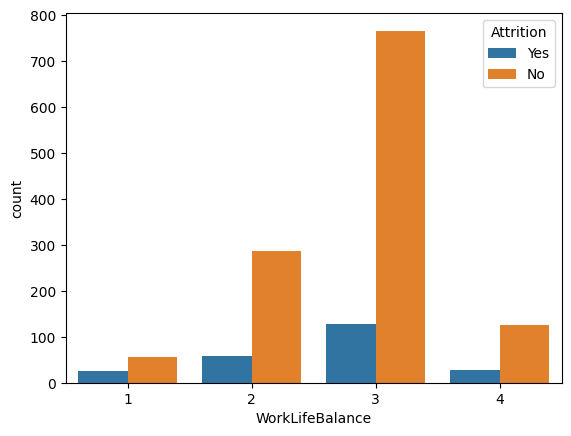

In [26]:
sns.countplot(
x='WorkLifeBalance',
hue='Attrition',
data=df
)

<Axes: xlabel='JobSatisfaction', ylabel='count'>

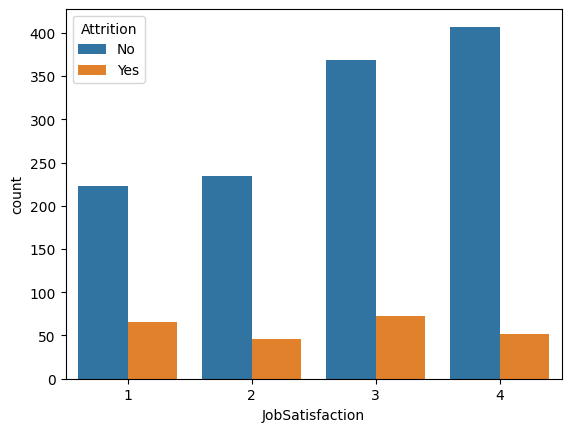

In [27]:
sns.countplot(
x='JobSatisfaction',
hue='Attrition',
data=df
)

<Axes: xlabel='EnvironmentSatisfaction', ylabel='count'>

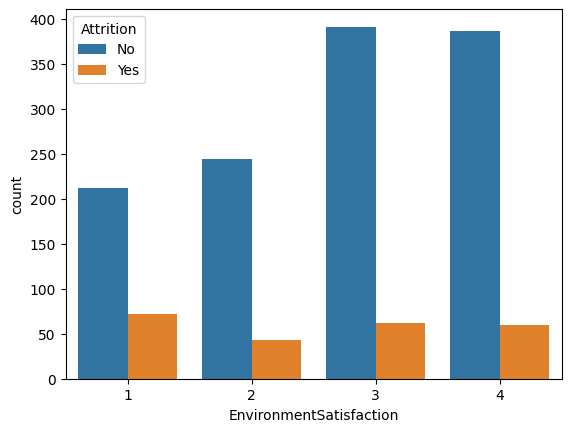

In [28]:
sns.countplot(
x='EnvironmentSatisfaction',
hue='Attrition',
data=df
)

<Axes: xlabel='Attrition', ylabel='DistanceFromHome'>

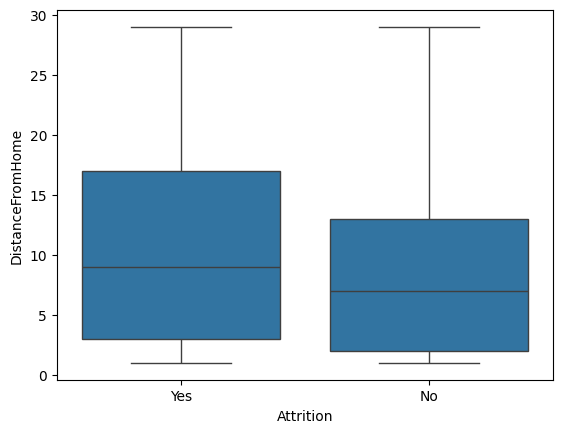

In [29]:
sns.boxplot(
x='Attrition',
y='DistanceFromHome',
data=df
)

<Axes: xlabel='Attrition', ylabel='YearsAtCompany'>

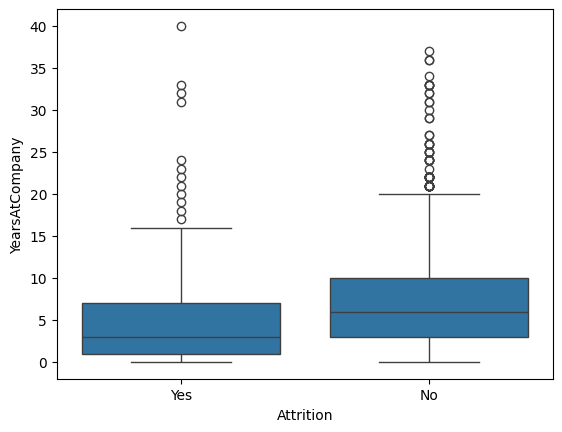

In [30]:
sns.boxplot(
x='Attrition',
y='YearsAtCompany',
data=df
)

<Axes: xlabel='BusinessTravel', ylabel='count'>

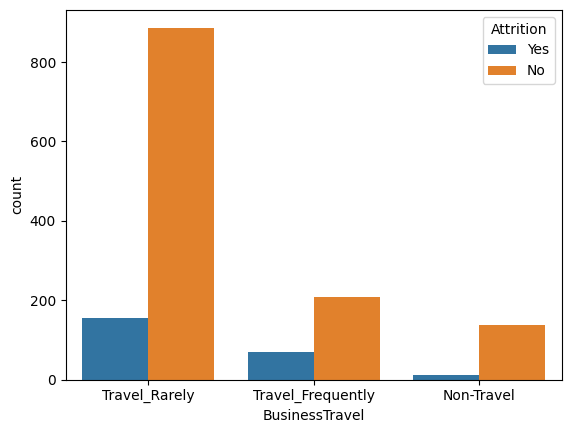

In [31]:
sns.countplot(
x='BusinessTravel',
hue='Attrition',
data=df
)

<Axes: xlabel='MaritalStatus', ylabel='count'>

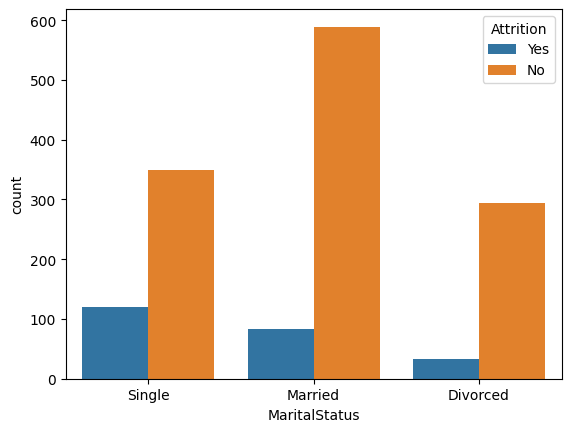

In [32]:
sns.countplot(
x='MaritalStatus',
hue='Attrition',
data=df
)

<Axes: xlabel='count', ylabel='EducationField'>

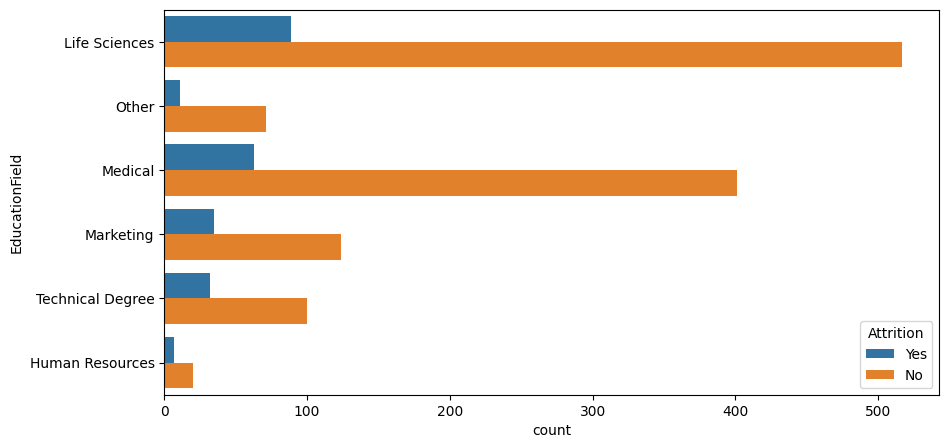

In [33]:
plt.figure(figsize=(10,5))

sns.countplot(
y='EducationField',
hue='Attrition',
data=df
)

<Axes: xlabel='Attrition', ylabel='Age'>

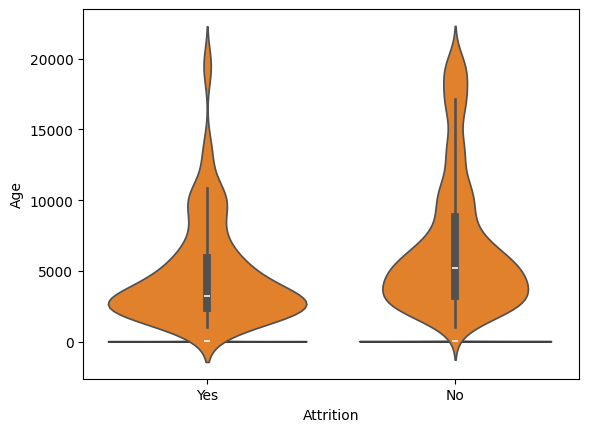

In [34]:
sns.violinplot(
x='Attrition',
y='Age',
data=df
)

sns.violinplot(
x='Attrition',
y='MonthlyIncome',
data=df
)

<Axes: xlabel='MonthlyIncome', ylabel='Density'>

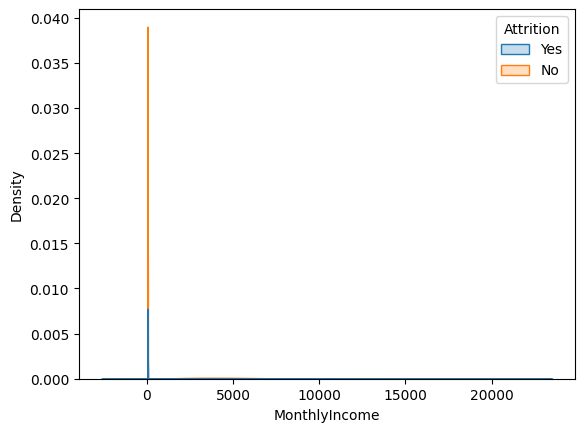

In [35]:
sns.kdeplot(
data=df,
x='MonthlyIncome',
hue='Attrition',
fill=True
)

sns.kdeplot(
data=df,
x='Age',
hue='Attrition',
fill=True
)

In [36]:
pd.crosstab(df['OverTime'],df['Attrition'],normalize='index')*100

pd.crosstab(df['JobRole'],df['Attrition'],normalize='index')*100

pd.crosstab(df['Department'],df['Attrition'],normalize='index')*100

Attrition,No,Yes
Department,,
Human Resources,80.952381,19.047619
Research & Development,86.160250,13.839750
Sales,79.372197,20.627803


# Inference

- The dataset has 1,470 employee records with no missing values or duplicates, making it suitable for analysis.
- Three columns (EmployeeCount, Over18, StandardHours) are constant and can be removed.
- The target variable is imbalanced, with roughly 84% of employees staying and 16% leaving.
- Employees working overtime exhibit significantly higher attrition.
- Younger employees and those with lower monthly incomes are more likely to leave.
- Job satisfaction, environment satisfaction, and work-life balance show inverse relationships with attrition.
- Employees with fewer years at the company tend to leave more frequently than long-tenured employees.
- MonthlyIncome, OverTime, Age, TotalWorkingYears, and JobLevel emerge as the most influential features for predicting attrition.